# Explainability and Experiment Tracking

Uses SHAP to explain the XGBoost model, and logs runs to MLflow for tracking.

In [1]:
import pandas as pd
import numpy as np
import shap
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

c:\Users\lenovo\Downloads\ecommerce-demand-forecasting\ecommerce-demand-forecasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading the processed training data.

In [2]:
#load the data
X_train = pd.read_csv('../data/X_train_processed.csv')
y = pd.read_csv('../data/y_train.csv').squeeze() 



Best parameters found in the tuning notebook.

In [3]:
# LightGBM and XGBoost best params
best_lgb_params = {
    'n_estimators': 484,
    'learning_rate': 0.048449507395808,
    'max_depth': 3,
    'num_leaves': 86,
    'min_child_samples': 41,
    'subsample': 0.6136190212931089,
    'colsample_bytree': 0.5831441550621443,
    'reg_alpha': 0.0656328005004874,
    'reg_lambda': 0.00807632423312057,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

best_xgb_params = {
    'n_estimators': 954,
    'learning_rate': 0.0309441972189576,
    'max_depth': 3,
    'min_child_weight': 2,
    'subsample': 0.5308834447818604,
    'colsample_bytree': 0.8741651968169409,
    'reg_alpha': 0.002157535703311696,
    'reg_lambda': 6.1321444386836506,
    'random_state': 42,
    'n_jobs': -1
}


Training XGBoost and LightGBM on the full training data.

In [4]:
# Train XGBoost on full data - best model for SHAP
xgb_model = xgb.XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train, y)

# Train LightGBM
lgb_model = lgb.LGBMRegressor(**best_lgb_params)
lgb_model.fit(X_train, y)


,num_leaves,86
,max_depth,3
,learning_rate,0.048449507395808
,n_estimators,484
,min_child_samples,41
,subsample,0.6136190212931089
,colsample_bytree,0.5831441550621443
,reg_alpha,0.0656328005004874
,reg_lambda,0.00807632423312057
,random_state,42
,n_jobs,-1


Building a SHAP explainer for the XGBoost model.

In [5]:
# Create SHAP explainer
# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for training data
# This tells us how each feature contributed to each prediction
print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_train)

print(f"SHAP values shape: {shap_values.shape}")
# Same shape as X_train - one SHAP value per feature per sample

Calculating SHAP values...
SHAP values shape: (1456, 238)


SHAP summary plot, shows overall feature importance and how each feature pushes predictions up or down.

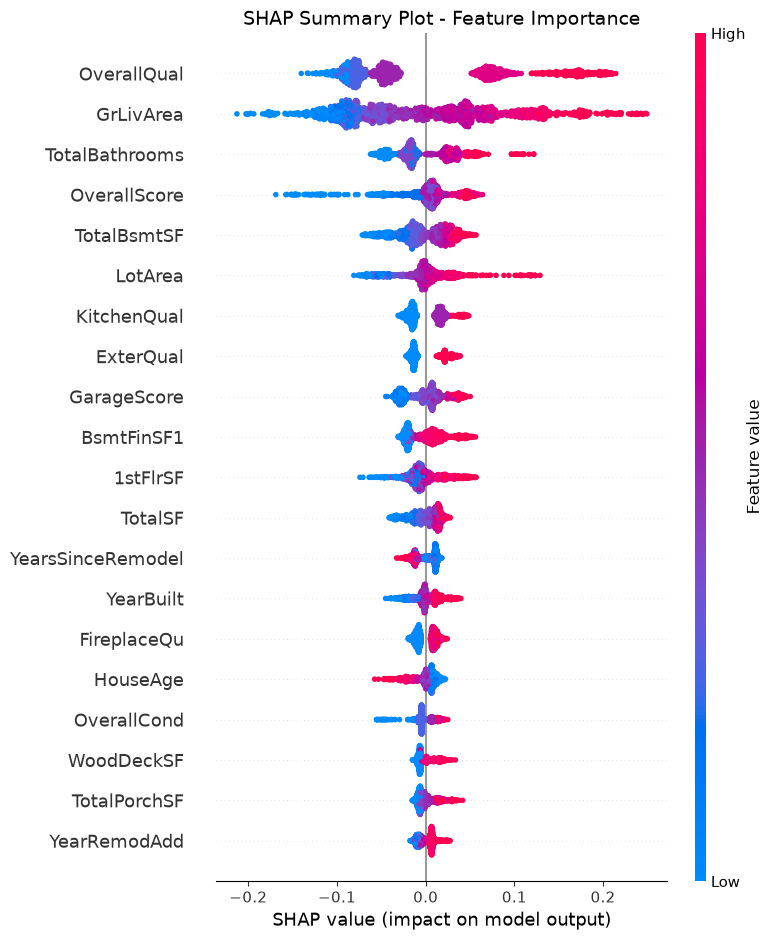

Summary plot saved


In [6]:
# Summary Plot
# Most important visualization - shows global feature importance
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_train,
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot - Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig('../results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved")

Waterfall plot for a single prediction, the most expensive house in the training data.

 97%|=================== | 1409/1456 [00:12<00:00]       

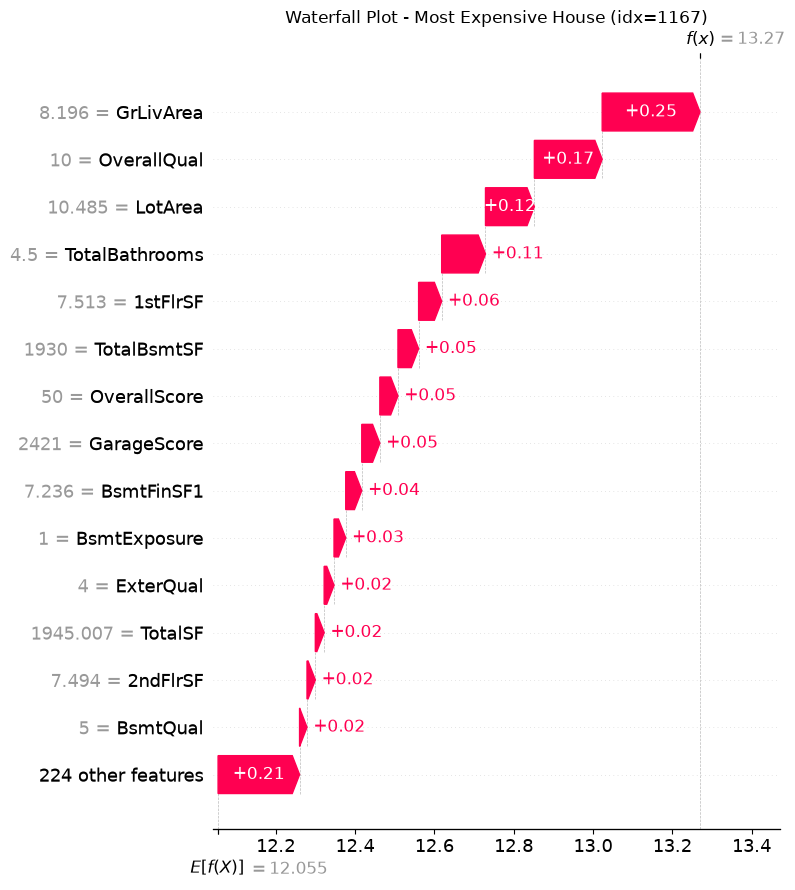

Actual price:    $625,000
Predicted price: $579,430
Error:           $45,570


In [7]:
#Waterfall Plot (Single Prediction)

X_train_float = X_train.astype(float)

# Waterfall Plot
most_expensive_idx = y.argmax()

explainer_v2 = shap.Explainer(xgb_model, X_train_float)
shap_explanation = explainer_v2(X_train_float)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(
    shap_explanation[most_expensive_idx],
    max_display=15,
    show=False
)
plt.title(f'Waterfall Plot - Most Expensive House (idx={most_expensive_idx})')
plt.tight_layout()
plt.savefig('../results/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

actual_price = np.expm1(y.iloc[most_expensive_idx])
predicted_price = np.expm1(xgb_model.predict(X_train_float.iloc[[most_expensive_idx]])[0])
print(f"Actual price:    ${actual_price:,.0f}")
print(f"Predicted price: ${predicted_price:,.0f}")
print(f"Error:           ${abs(actual_price-predicted_price):,.0f}")

Dependence plots, showing how OverallQual and TotalSF affect predictions.

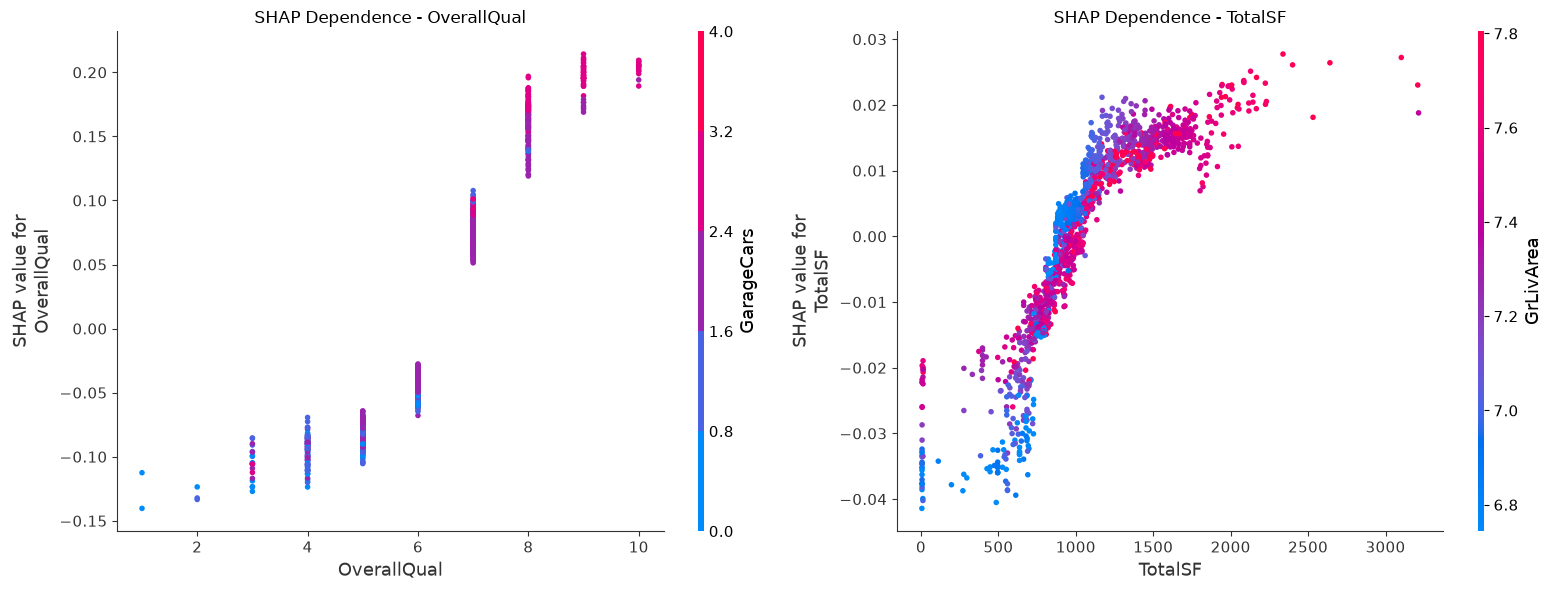

In [8]:
#Dependence Plots
# How does OverallQual affect predictions?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OverallQual dependence
shap.dependence_plot(
    'OverallQual',
    shap_values,
    X_train,
    ax=axes[0],
    show=False
)

axes[0].set_title('SHAP Dependence - OverallQual')

# TotalSF dependence
shap.dependence_plot(
    'TotalSF',
    shap_values,
    X_train,
    ax=axes[1],
    show=False
)
axes[1].set_title('SHAP Dependence - TotalSF')

plt.tight_layout()
plt.savefig('../results/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

Logging model runs to MLflow for tracking.

In [9]:
#MLflow Experiment Tracking
# Set up MLflow
mlflow.set_experiment("House_Price_Prediction")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model, X, y):
    scores = -cross_val_score(
        model, X, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    return scores.mean(), scores.std()

# Log all models as MLflow runs
models_to_log = {
    'Ridge_baseline': Pipeline([
        ('scaler', RobustScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'XGBoost_tuned': xgb.XGBRegressor(**best_xgb_params),
    'LightGBM_tuned': lgb.LGBMRegressor(**best_lgb_params),
}

for model_name, model in models_to_log.items():
    with mlflow.start_run(run_name=model_name):
        # Calculate metrics
        rmse_mean, rmse_std = rmse_cv(model, X_train, y)
        
        # Log parameters
        if hasattr(model, 'get_params'):
            mlflow.log_params(model.get_params())
        
        # Log metrics
        mlflow.log_metric('rmse_mean', rmse_mean)
        mlflow.log_metric('rmse_std', rmse_std)
        
        # Train and log model
        model.fit(X_train, y)
        
        print(f" {model_name}: RMSE={rmse_mean:.4f} +/- {rmse_std:.4f}")

print("\nAll runs logged to MLflow")

2026/08/12 14:11:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/12 14:11:00 INFO mlflow.store.db.utils: Updating database tables
2026/08/12 14:11:06 INFO mlflow.tracking.fluent: Experiment with name 'House_Price_Prediction' does not exist. Creating a new experiment.


 Ridge_baseline: RMSE=0.1119 +/- 0.0081
 XGBoost_tuned: RMSE=0.1159 +/- 0.0111
 LightGBM_tuned: RMSE=0.1184 +/- 0.0129

All runs logged to MLflow


Comparing SHAP importance against XGBoost's built in feature importance.

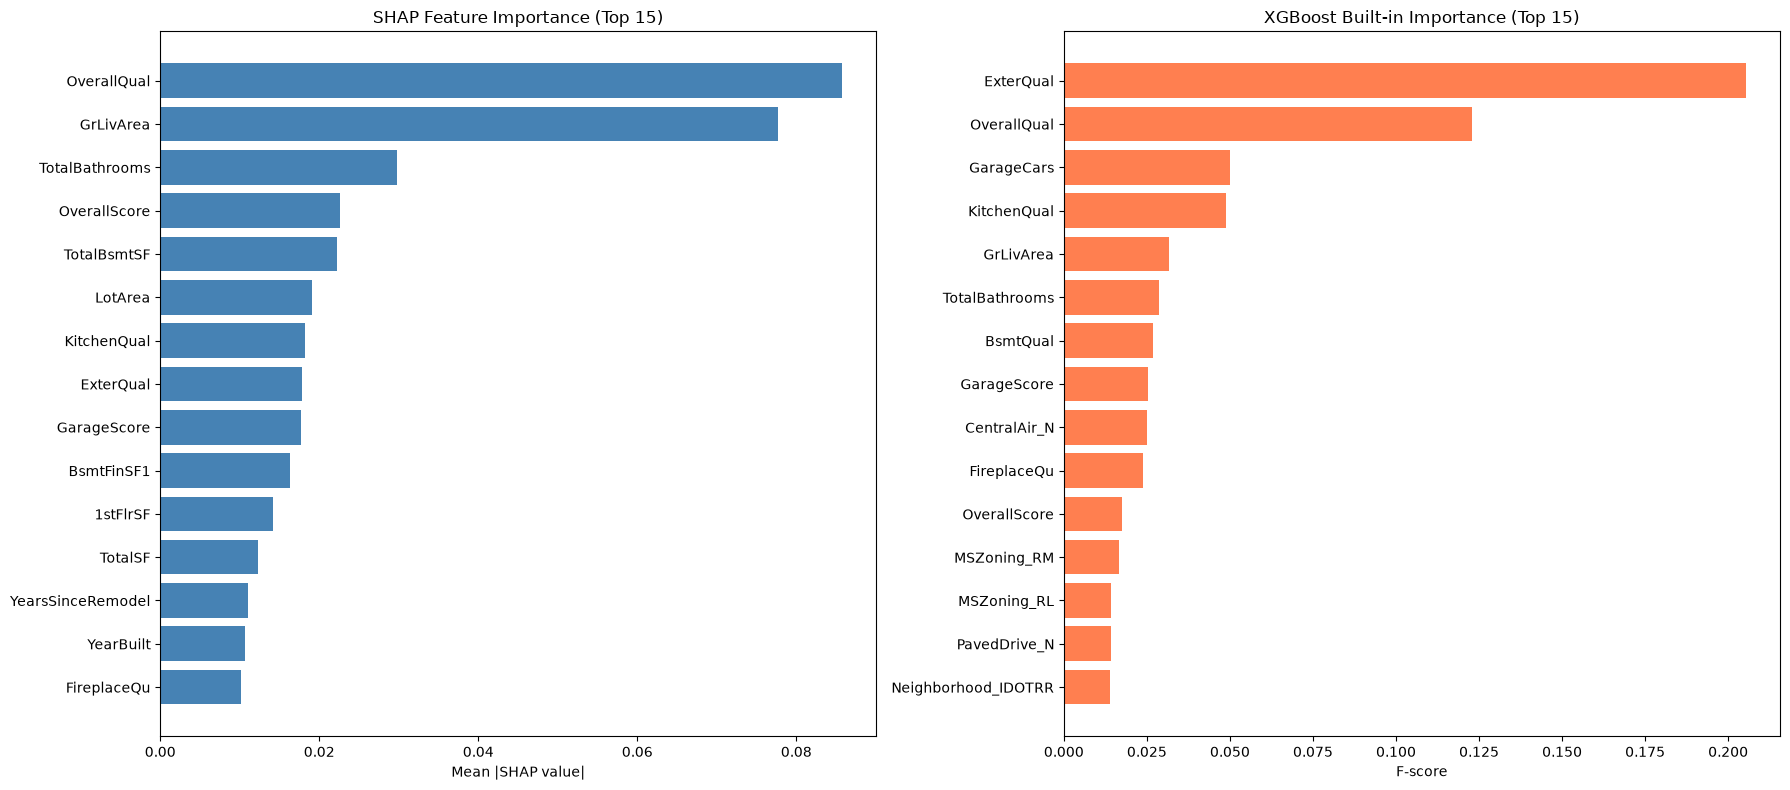

In [10]:
# Compare SHAP importance vs built-in importance
shap_importance = pd.DataFrame({
    'feature': X_train.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False).head(15)

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgb_importance': xgb_model.feature_importances_
}).sort_values('xgb_importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# SHAP importance
axes[0].barh(shap_importance['feature'][::-1],
             shap_importance['shap_importance'][::-1],
             color='steelblue')
axes[0].set_title('SHAP Feature Importance (Top 15)')
axes[0].set_xlabel('Mean |SHAP value|')

# XGBoost built-in importance
axes[1].barh(xgb_importance['feature'][::-1],
             xgb_importance['xgb_importance'][::-1],
             color='coral')
axes[1].set_title('XGBoost Built-in Importance (Top 15)')
axes[1].set_xlabel('F-score')

plt.tight_layout()
plt.savefig('../results/feature_importance_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()